In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('CostReport_2023_Final.csv')

In [4]:
df.head()

,rpt_rec_num,Provider CCN,Hospital Name,Street Address,City,State Code,Zip Code,County,Medicare CBSA Number,Rural Versus Urban,...,Net Income from Service to Patients,Total Other Income,Total Income,Total Other Expenses,Net Income,Cost To Charge Ratio,Net Revenue from Medicaid,Medicaid Charges,Net Revenue from Stand-Alone CHIP,Stand-Alone CHIP Charges
0,747534,110130,IRWIN COUNTY HOSPITAL,710 NORTH IRWIN AVENUE,OCILLA,GA,31774,IRWIN,99911.0,R,...,-1475853.0,227033.0,-1248820.0,NaN,-1248820.0,0.426683,30844.0,140289.0,13.0,212.0
1,748262,144042,LAKE BEHAVIORAL HOSPITAL,2615 WASHINGTON ST,WAUKEGAN,IL,60085,LAKE,29404.0,U,...,1198476.0,1434403.0,2632879.0,NaN,2632879.0,NaN,NaN,NaN,NaN,NaN
2,748457,43036,EVEREST REHABILITATION HOSPITAL BENT,4313 S PLEASANT CROSSING BLVD,ROGERS,AR,72758-1347,BENTON,22220.0,U,...,-997485.0,478980.0,-518505.0,NaN,-518505.0,NaN,NaN,NaN,NaN,NaN
3,748589,454155,OCEANS BEHAVIORAL HOSPITAL CORPUS CH,600 ELIZABETH ST BUILDING B 4TH FLO,CORPUS CHRISTI,TX,78404,NUECES,18580.0,U,...,-2183467.0,170.0,-2183297.0,NaN,-2183297.0,NaN,NaN,NaN,NaN,NaN
4,748617,144043,MONTROSE BEHAVIORAL HEALTH HOSPITAL,4720 NORTH CLARENDON AVENUE,CHICAGO,IL,60640-5122,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.tail()


,rpt_rec_num,Provider CCN,Hospital Name,Street Address,City,State Code,Zip Code,County,Medicare CBSA Number,Rural Versus Urban,...,Net Income from Service to Patients,Total Other Income,Total Income,Total Other Expenses,Net Income,Cost To Charge Ratio,Net Revenue from Medicaid,Medicaid Charges,Net Revenue from Stand-Alone CHIP,Stand-Alone CHIP Charges
6098,807239,220030,BAYSTATE WING HOSPITAL & MEDICAL CTR,40 WRIGHT STREET,PALMER,MA,01069,NaN,44140.0,U,...,-7903843.0,6556930.0,-1346913.0,NaN,-1346913.0,0.0,19159126.0,55467523.0,NaN,NaN
6099,807244,251331,BMH - CALHOUN,140 BURKE CALHOUN CITY ROAD,CALHOUN,MS,38916,CALHOUN,99925.0,R,...,-434918.0,1272203.0,837285.0,NaN,837285.0,1.0,992329.0,3420392.0,22154.0,52606.0
6100,807290,450771,TEXAS HEALTH PRESBYTERIAN HOSPITAL P,6200 WEST PARKER ROAD,PLANO,TX,75093,COLLIN,19124.0,U,...,95471661.0,4402332.0,99873993.0,NaN,99873993.0,0.0,18403527.0,97104801.0,NaN,NaN
6101,807296,470003,UNIVERSITY OF VERMONT MEDICAL CENTER,111 COLCHESTER AVENUE,BURLINGTON,VT,05401,CHITTENDEN,15540.0,R,...,-209065452.0,328946452.0,119881000.0,NaN,119881000.0,0.0,98671557.0,548187058.0,NaN,NaN
6102,807303,670090,CRESCENT MEDICAL CENTER LANCASTER,2600 W. PLEASANT RUN RD.,LANCASTER,TX,75146,DALLAS,19124.0,U,...,-1960898.0,6179409.0,4218511.0,NaN,4218511.0,0.0,19106.0,214755.0,NaN,NaN


In [2]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6103 entries, 0 to 6102
Columns: 117 entries, rpt_rec_num to Stand-Alone CHIP Charges
dtypes: float64(103), int64(4), object(10)
memory usage: 5.2+ MB


(6103, 117)

In [6]:
df.describe()

,rpt_rec_num,Provider CCN,Medicare CBSA Number,Provider Type,Type of Control,FTE - Employees on Payroll,Number of Interns and Residents (FTE),Total Days Title V,Total Days Title XVIII,Total Days Title XIX,...,Net Income from Service to Patients,Total Other Income,Total Income,Total Other Expenses,Net Income,Cost To Charge Ratio,Net Revenue from Medicaid,Medicaid Charges,Net Revenue from Stand-Alone CHIP,Stand-Alone CHIP Charges
count,6103.000000,6103.000000,6021.000000,6103.000000,6103.000000,5962.000000,1523.000000,127.000000,5920.000000,5056.000000,...,6.019000e+03,5.799000e+03,6.015000e+03,1.727000e+03,6.014000e+03,4613.000000,4.378000e+03,4.360000e+03,9.520000e+02,9.620000e+02
mean,785008.763559,270290.338358,52928.217074,1.755694,4.178928,977.036184,93.850519,2714.543307,7222.899155,3333.490704,...,-1.069181e+07,2.819683e+07,1.648536e+07,3.628116e+06,1.544624e+07,1.215057,3.348602e+07,2.055063e+08,7.778439e+05,5.644722e+06
std,11943.807349,161725.968794,33991.617314,1.546861,3.194775,4387.357952,168.440715,6731.310188,11807.654450,8131.646390,...,1.276946e+08,1.178323e+08,1.074866e+08,5.424278e+07,1.058836e+08,46.089181,9.327470e+07,4.627638e+08,3.180967e+06,3.569574e+07
min,747534.000000,10001.000000,10180.000000,1.000000,1.000000,0.050000,0.000000,1.000000,1.000000,1.000000,...,-3.979088e+09,-1.693180e+09,-3.955820e+09,-1.234801e+09,-3.955820e+09,0.000000,-2.089892e+07,1.000000e+00,-3.102300e+04,2.120000e+02
25%,775263.500000,140152.500000,26420.000000,1.000000,2.000000,129.080000,8.275000,143.500000,899.000000,103.000000,...,-1.056666e+07,6.939985e+05,-1.570995e+06,-6.000000e+00,-1.702859e+06,0.177129,2.747788e+06,1.098586e+07,2.047800e+04,1.234550e+05
50%,785911.000000,260006.000000,39100.000000,1.000000,2.000000,287.490000,28.620000,885.000000,2561.500000,648.500000,...,-1.335362e+06,3.212208e+06,2.245618e+06,2.153500e+04,2.045326e+06,0.270039,9.313046e+06,5.331015e+07,8.568150e+04,6.043595e+05
75%,794696.500000,393179.000000,99916.000000,1.000000,5.000000,911.427500,92.185000,2552.500000,8762.750000,2883.000000,...,4.753553e+06,1.341372e+07,1.403540e+07,1.104484e+06,1.316970e+07,0.463456,2.902951e+07,2.009139e+08,3.278190e+05,2.354091e+06
max,807303.000000,713029.000000,99966.000000,12.000000,13.000000,295330.130000,1968.000000,59573.000000,208248.000000,183050.000000,...,2.220032e+09,2.658138e+09,2.224171e+09,6.916362e+08,2.224171e+09,3110.668074,3.300915e+09,9.319141e+09,4.598930e+07,8.917134e+08


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
rpt_rec_num,6103.0,7.850088e+05,1.194381e+04,747534.0,7.752635e+05,7.859110e+05,7.946965e+05,8.073030e+05
Provider CCN,6103.0,2.702903e+05,1.617260e+05,10001.0,1.401525e+05,2.600060e+05,3.931790e+05,7.130290e+05
Medicare CBSA Number,6021.0,5.292822e+04,3.399162e+04,10180.0,2.642000e+04,3.910000e+04,9.991600e+04,9.996600e+04
Provider Type,6103.0,1.755694e+00,1.546861e+00,1.0,1.000000e+00,1.000000e+00,1.000000e+00,1.200000e+01
Type of Control,6103.0,4.178928e+00,3.194775e+00,1.0,2.000000e+00,2.000000e+00,5.000000e+00,1.300000e+01
...,...,...,...,...,...,...,...,...
Cost To Charge Ratio,4613.0,1.215057e+00,4.608918e+01,0.0,1.771290e-01,2.700390e-01,4.634560e-01,3.110668e+03
Net Revenue from Medicaid,4378.0,3.348602e+07,9.327470e+07,-20898919.0,2.747788e+06,9.313046e+06,2.902951e+07,3.300915e+09
Medicaid Charges,4360.0,2.055063e+08,4.627638e+08,1.0,1.098586e+07,5.331015e+07,2.009139e+08,9.319141e+09
Net Revenue from Stand-Alone CHIP,952.0,7.778439e+05,3.180967e+06,-31023.0,2.047800e+04,8.568150e+04,3.278190e+05,4.598930e+07


In [8]:
df.columns

Index(['rpt_rec_num', 'Provider CCN', 'Hospital Name', 'Street Address',
       'City', 'State Code', 'Zip Code', 'County', 'Medicare CBSA Number',
       'Rural Versus Urban',
       ...
       'Net Income from Service to Patients', 'Total Other Income',
       'Total Income', 'Total Other Expenses', 'Net Income',
       'Cost To Charge Ratio', 'Net Revenue from Medicaid', 'Medicaid Charges',
       'Net Revenue from Stand-Alone CHIP', 'Stand-Alone CHIP Charges'],
      dtype='object', length=117)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().sum()

rpt_rec_num                             0
Provider CCN                            0
Hospital Name                           0
Street Address                          3
City                                    0
                                     ... 
Cost To Charge Ratio                 1490
Net Revenue from Medicaid            1725
Medicaid Charges                     1743
Net Revenue from Stand-Alone CHIP    5151
Stand-Alone CHIP Charges             5141
Length: 117, dtype: int64

In [11]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna('Unknown')
    else:
        df[col] = df[col].fillna(df[col].median())

/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [12]:
print(df.isnull().sum())

rpt_rec_num                          0
Provider CCN                         0
Hospital Name                        0
Street Address                       0
City                                 0
                                    ..
Cost To Charge Ratio                 0
Net Revenue from Medicaid            0
Medicaid Charges                     0
Net Revenue from Stand-Alone CHIP    0
Stand-Alone CHIP Charges             0
Length: 117, dtype: int64


In [13]:
df.to_csv('Cleaned_Cost_Report_Hospital.csv', index = False)

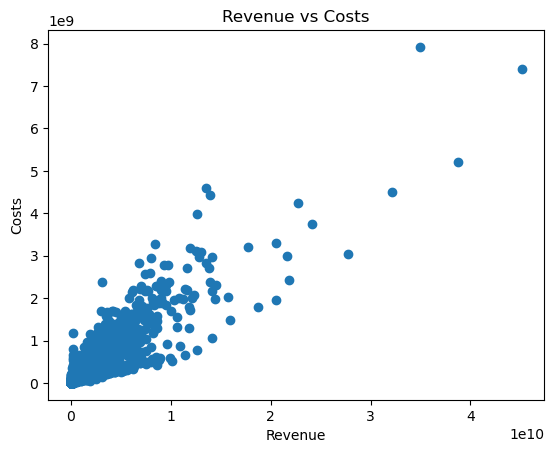

In [15]:
plt.scatter(df['Total Patient Revenue'], df['Total Costs'])
plt.xlabel('Revenue')
plt.ylabel('Costs')
plt.title('Revenue vs Costs')
plt.show()

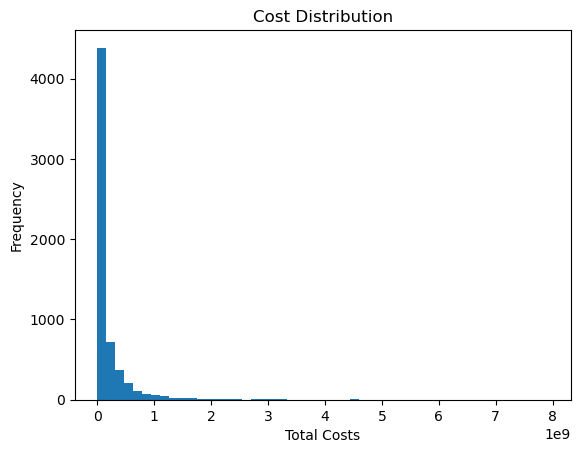

In [16]:
plt.hist(df['Total Costs'], bins=50)
plt.title('Cost Distribution')
plt.xlabel('Total Costs')
plt.ylabel('Frequency')
plt.show()